In [1]:
import polars as pl 
import seaborn as sns 
import matplotlib.pyplot as plt 
from dbconfig import engine 
print('Environment ready!')

Environment ready!


In [2]:
from pathlib import Path 

plots_dir = Path('plots')
plots_dir.mkdir(exist_ok = True)

In [3]:
pl.Config.set_tbl_rows(50)
pl.Config.set_tbl_cols(30)
pl.Config.set_fmt_str_lengths(80)
pl.Config.set_tbl_width_chars(180)
pl.Config.set_float_precision(2)
pl.Config.set_thousands_separator(",")

polars.config.Config

In [11]:
pl.read_database(
        query = """
        select order_status,
        count(*)
        from clean.orders 
        group by 1
        order by 2 desc;
        """, connection = engine
        )

order_status,count
str,i64
"""delivered""","96,478"
"""shipped""","1,107"
"""canceled""",625
"""unavailable""",609
"""invoiced""",314
"""processing""",301
"""created""",5
"""approved""",2


In [9]:
pl.read_database(
        query = """
        select column_name
        from information_schema.columns 
        where table_name = 'orders'
        and table_schema = 'clean'
        order by 1;
        """, connection = engine 
        )

column_name
str
"""customer_id"""
"""order_approved_at"""
"""order_delivered_carrier_date"""
"""order_delivered_customer_date"""
"""order_estimated_delivery_date"""
"""order_id"""
"""order_purchase_timestamp"""
"""order_status"""


In [14]:
delivery_df = pl.read_database(
        query = """
        select *
        from clean.orders;
        """, connection = engine
        )

In [15]:
delivery_df.select(
        pl.all().null_count()
        )

order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,160,"1,783","2,965",0


In [19]:
delivery_df.filter(
        pl.col('order_status') == 'delivered').select(
                pl.all().null_count())

order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,14,2,8,0


In [23]:
delivery_df = delivery_df.filter(
        (pl.col('order_status') == 'delivered')
        &
        (pl.col('order_delivered_customer_date').is_not_null())
        &
        (pl.col('order_delivered_carrier_date').is_not_null())
        &
        (pl.col('order_approved_at').is_not_null())
        )

In [24]:
delivery_df.select(
        pl.all().null_count()
        )

order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0,0


In [25]:
delivery_df = (
    delivery_df
    .with_columns(
        (
            pl.col("order_delivered_customer_date")
            - pl.col("order_purchase_timestamp")
        ).dt.total_days().alias("delivery_days"),

        (
            pl.col("order_delivered_customer_date")
            - pl.col("order_estimated_delivery_date")
        ).dt.total_days().alias("delay_days"),

        (
            pl.col("order_approved_at")
            - pl.col("order_purchase_timestamp")
        ).dt.total_hours().alias("approval_hours"),

        (
            pl.col("order_delivered_carrier_date")
            - pl.col("order_approved_at")
        ).dt.total_days().alias("seller_handoff_days"),

        (
            pl.col("order_delivered_customer_date")
            - pl.col("order_delivered_carrier_date")
        ).dt.total_days().alias("carrier_delivery_days")
    )
)

In [27]:
delivery_df.select('delivery_days').describe()

statistic,delivery_days
str,f64
"""count""","96,455.00"
"""null_count""",0.00
"""mean""",12.09
"""std""",9.55
"""min""",0.00
"""25%""",6.00
"""50%""",10.00
"""75%""",15.00
"""max""",209.00


In [28]:
delivery_df.sort('delivery_days', descending = True).head(20)

order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,delay_days,approval_hours,seller_handoff_days,carrier_delivery_days
str,str,str,datetime[μs],datetime[μs],datetime[μs],datetime[μs],datetime[μs],i64,i64,i64,i64,i64
"""ca07593549f1816d26a572e06dc1eab6""","""75683a92331068e2d281b11a7866ba44""","""delivered""",2017-02-21 23:31:27,2017-02-23 02:35:15,2017-03-08 13:47:46,2017-09-19 14:36:39,2017-03-22 00:00:00,209,181,27,13,195
"""1b3190b2dfa9d789e1f14c05b647a14a""","""d306426abe5fca15e54b645e4462dc7b""","""delivered""",2018-02-23 14:57:35,2018-02-23 15:16:14,2018-02-26 18:49:07,2018-09-19 23:24:07,2018-03-15 00:00:00,208,188,0,3,205
"""440d0d17af552815d15a9e41abe49359""","""7815125148cfa1e8c7fee1ff7974f16c""","""delivered""",2017-03-07 23:59:51,2017-03-09 01:11:33,2017-03-15 13:00:08,2017-09-19 15:12:50,2017-04-07 00:00:00,195,165,25,6,188
"""0f4519c5f1c541ddec9f21b3bddd533a""","""1a8a4a30dc296976717f44e7801fdeef""","""delivered""",2017-03-09 13:26:57,2017-03-09 13:26:57,2017-03-22 05:28:14,2017-09-19 14:38:21,2017-04-11 00:00:00,194,161,0,12,181
"""2fb597c2f772eca01b1f5c561bf6cc7b""","""217906bc11a32c1e470eb7e08584894b""","""delivered""",2017-03-08 18:09:02,2017-03-08 18:09:02,2017-03-13 08:54:02,2017-09-19 14:33:17,2017-04-17 00:00:00,194,155,0,4,190
"""285ab9426d6982034523a855f55a885e""","""9cf2c3fa2632cee748e1a59ca9d09b21""","""delivered""",2017-03-08 22:47:40,2017-03-08 22:47:40,2017-03-09 08:53:20,2017-09-19 14:00:04,2017-04-06 00:00:00,194,166,0,0,194
"""47b40429ed8cce3aee9199792275433f""","""cb2caaaead400c97350c37a3fc536867""","""delivered""",2018-01-03 09:44:01,2018-01-03 10:31:15,2018-02-06 01:48:28,2018-07-13 20:51:31,2018-01-19 00:00:00,191,175,0,33,157
"""2fe324febf907e3ea3f2aa9650869fa5""","""65b14237885b3972ebec28c0f7dd2220""","""delivered""",2017-03-13 20:17:10,2017-03-13 20:17:10,2017-03-17 07:23:53,2017-09-19 17:00:07,2017-04-05 00:00:00,189,167,0,3,186
"""2d7561026d542c8dbd8f0daeadf67a43""","""8199345f57c6d1cbe9701f92481beb8d""","""delivered""",2017-03-15 11:24:27,2017-03-15 11:24:27,2017-03-16 09:29:16,2017-09-19 14:38:18,2017-04-13 00:00:00,188,159,0,0,187


In [30]:
delivery_df.filter(
        pl.col('delivery_days') > 100
        ).describe()

statistic,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,delay_days,approval_hours,seller_handoff_days,carrier_delivery_days
str,str,str,str,str,str,str,str,str,f64,f64,f64,f64,f64
"""count""","""63""","""63""","""63""","""63""","""63""","""63""","""63""","""63""",63.00,63.00,63.00,63.00,63.00
"""null_count""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""",0.00,0.00,0.00,0.00,0.00
"""mean""",null,null,null,"""2017-08-19 00:57:45.634920""","""2017-08-19 10:38:12.206349""","""2017-08-29 03:16:17.317460""","""2018-01-11 00:43:18.920635""","""2017-09-17 04:34:17.142857""",144.57,115.17,9.38,9.25,134.43
"""std""",null,null,null,null,null,null,null,null,33.44,34.65,15.90,23.78,44.21
"""min""","""031e7d4e559a1bf08e71a419aa998d0a""","""033fab69968b0d69099d64423831a236""","""delivered""","""2017-01-12 12:01:14""","""2017-01-13 16:25:19""","""2017-01-16 16:10:12""","""2017-04-26 09:35:51""","""2017-03-06 00:00:00""",101.00,51.00,0.00,0.00,0.00
"""25%""",null,null,null,"""2017-03-29 13:57:55""","""2017-03-30 02:10:20""","""2017-03-30 16:09:39""","""2017-09-19 15:07:09""","""2017-05-04 00:00:00""",110.00,91.00,0.00,1.00,104.00
"""50%""",null,null,null,"""2017-08-25 19:11:04""","""2017-08-25 19:26:20""","""2017-08-30 16:24:39""","""2017-12-18 23:19:20""","""2017-09-12 00:00:00""",138.00,109.00,0.00,3.00,132.00
"""75%""",null,null,null,"""2017-12-18 20:15:41""","""2017-12-20 16:10:46""","""2018-01-26 18:22:07""","""2018-05-10 00:06:20""","""2018-01-19 00:00:00""",174.00,144.00,22.00,5.00,169.00
"""max""","""fbee80ef6891c144af8ff9dc788aaa89""","""fc99aeadad12e8925f558305956a08aa""","""delivered""","""2018-06-02 18:37:14""","""2018-06-02 18:51:31""","""2018-06-04 13:42:00""","""2018-10-17 13:22:46""","""2018-07-13 00:00:00""",209.00,188.00,70.00,125.00,205.00


In [33]:
delivery_df.filter(
    pl.col("delivery_days") > 100
).group_by(
    pl.col("order_delivered_customer_date").dt.date()
).len().sort("len", descending=True).head()

order_delivered_customer_date,len
date,u32
2017-09-19,21
2018-05-10,1
2017-05-25,1
2018-04-03,1
2018-04-28,1


In [32]:
delivery_df.select(
    pl.col("delay_days")
).describe()

statistic,delay_days
str,f64
"""count""","96,455.00"
"""null_count""",0.00
"""mean""",-10.96
"""std""",10.02
"""min""",-146.00
"""25%""",-16.00
"""50%""",-11.00
"""75%""",-6.00
"""max""",188.00


In [34]:
delivery_df.head()

order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,delay_days,approval_hours,seller_handoff_days,carrier_delivery_days
str,str,str,datetime[μs],datetime[μs],datetime[μs],datetime[μs],datetime[μs],i64,i64,i64,i64,i64
"""e481f51cbdc54678b7cc49136f2d6af7""","""9ef432eb6251297304e76186b10a928d""","""delivered""",2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,8,-7,0,2,6
"""53cdb2fc8bc7dce0b6741e2150273451""","""b0830fb4747a6c6d20dea0b8c802d7ef""","""delivered""",2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,13,-5,30,0,12
"""47770eb9100c2d0c44946d9cf07ec65d""","""41ce2a54c0b03bf3443c3d931a367089""","""delivered""",2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,9,-17,0,0,9
"""949d5b44dbf5de918fe9c16f97b45f8a""","""f88197465ea7920adcdbec7375364d82""","""delivered""",2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,13,-12,0,3,9
"""ad21c59c0840e6cb83a9ceb5573f8159""","""8ab97904e6daea8866dbdbc4fb7aad2c""","""delivered""",2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,2,-9,1,0,1


In [37]:
category_delivery_df = pl.read_database(
        query = """
        select o.order_id,

        c.product_category_name_english as category,

        extract(
            day from (
                o.order_delivered_customer_date 
                - o.order_purchase_timestamp
                )
            ) as delivery_days,

        extract( 
                day from (
                    o.order_delivered_customer_date 
                    - o.order_estimated_delivery_date
                    )
            ) as delay_days

        from clean.orders o

        join clean.order_items oi 
        on o.order_id = oi.order_id 

        join clean.products p 
        on oi.product_id = p.product_id 

        join clean.categories c 
        on p.product_category_name = c.product_category_name 

        where order_status = 'delivered';
        """, connection = engine
        )

In [38]:
category_delivery_df.head()

order_id,category,delivery_days,delay_days
str,str,"decimal[38,0]","decimal[38,0]"
"""00018f77f2f0320c557190d7a144bdd3""","""pet_shop""",16,-2
"""000229ec398224ef6ca0657da4fc703e""","""furniture_decor""",7,-13
"""00042b26cf59d7ce69dfabb4e55b4fd9""","""garden_tools""",25,-15
"""00048cc3ae777c65dbb7d2a0634bc1ea""","""housewares""",6,-14
"""00054e8431b9d7675808bcb819fb4a32""","""telephony""",8,-16


In [39]:
category_delivery_df.filter(
        pl.col('category').is_null()
        ).height

22

In [43]:
category_delivery_df = category_delivery_df.filter(
        pl.col('category').is_not_null()
        )

In [44]:
category_delivery_df.describe()

statistic,order_id,category,delivery_days,delay_days
str,str,str,f64,f64
"""count""","""108,638""","""108,638""","108,630.00","108,630.00"
"""null_count""","""0""","""0""",8.00,8.00
"""mean""",null,null,12.00,-11.12
"""std""",null,null,9.44,9.99
"""min""","""00010242fe8c5a6d1ba2dd792cb16214""","""agro_industry_and_commerce""",0.00,-146.00
"""25%""",null,null,6.00,-16.00
"""50%""",null,null,10.00,-12.00
"""75%""",null,null,15.00,-6.00
"""max""","""fffe41c64501cc87c801fd61db3f6244""","""watches_gifts""",209.00,188.00


In [45]:
category_delivery_df = category_delivery_df.drop_nulls(['order_id', 'delivery_days', 'delay_days'])

In [46]:
category_delivery_df.describe()

statistic,order_id,category,delivery_days,delay_days
str,str,str,f64,f64
"""count""","""108,630""","""108,630""","108,630.00","108,630.00"
"""null_count""","""0""","""0""",0.00,0.00
"""mean""",null,null,12.00,-11.12
"""std""",null,null,9.44,9.99
"""min""","""00010242fe8c5a6d1ba2dd792cb16214""","""agro_industry_and_commerce""",0.00,-146.00
"""25%""",null,null,6.00,-16.00
"""50%""",null,null,10.00,-12.00
"""75%""",null,null,15.00,-6.00
"""max""","""fffe41c64501cc87c801fd61db3f6244""","""watches_gifts""",209.00,188.00


In [48]:
category_counts = (
        category_delivery_df.group_by('category')
        .agg(
            pl.n_unique('order_id').alias('orders')
            )
        .sort('orders', descending = True)
        )

In [49]:
category_metrics = (
    category_delivery_df
    .group_by("category")
    .agg(
        pl.n_unique("order_id").alias("orders"),

        pl.col("delivery_days").median().alias("median_delivery_days"),
        pl.col("delivery_days").mean().alias("avg_delivery_days"),

        pl.col("delay_days").median().alias("median_delay_days"),
        pl.col("delay_days").mean().alias("avg_delay_days"),

        (pl.col("delay_days") > 0)
            .mean()
            .mul(100)
            .alias("late_pct")
    )
    .filter(pl.col("orders") >= 500)
)

In [50]:
category_metrics.sort(
    "median_delivery_days"
)

category,orders,median_delivery_days,avg_delivery_days,median_delay_days,avg_delay_days,late_pct
str,u32,f64,f64,f64,f64,f64
"""luggage_accessories""","1,019",8.00,10.19,-12.00,-11.67,4.18
"""construction_tools_construction""",736,8.00,10.29,-11.00,-10.70,6.33
"""housewares""","5,743",8.00,10.46,-12.00,-11.37,5.00
"""small_appliances""",609,8.00,10.33,-13.00,-12.94,4.56
"""fashion_bags_accessories""","1,820",8.00,10.61,-12.00,-12.40,5.29
"""health_beauty""","8,647",9.00,11.52,-12.00,-11.06,7.56
"""home_appliances""",747,9.00,10.87,-11.00,-11.72,4.51
"""pet_shop""","1,688",9.00,10.76,-12.00,-11.60,4.94
"""auto""","3,809",9.00,11.77,-11.00,-10.52,7.03


In [51]:
category_metrics.write_database(
    table_name="analytics.category_delivery_metrics",
    connection=engine,
    if_table_exists="replace"
)

-1

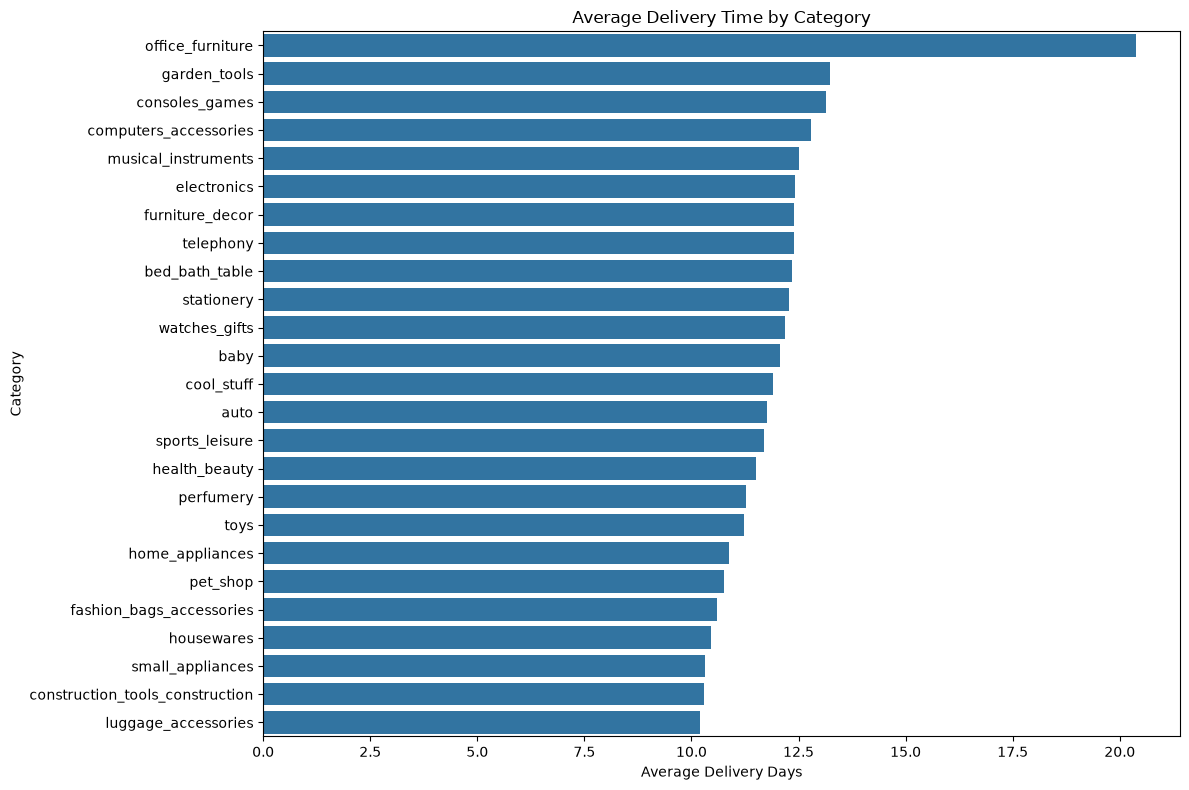

In [55]:
plot_df = (
    category_metrics
    .sort("avg_delivery_days", descending=True)
    .to_pandas()
)

plt.figure(figsize=(12, 8))

sns.barplot(
    data=plot_df,
    x="avg_delivery_days",
    y="category"
)

plt.title("Average Delivery Time by Category")
plt.xlabel("Average Delivery Days")
plt.ylabel("Category")

plt.tight_layout()

plt.savefig(
    "plots/category_delivery_time.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

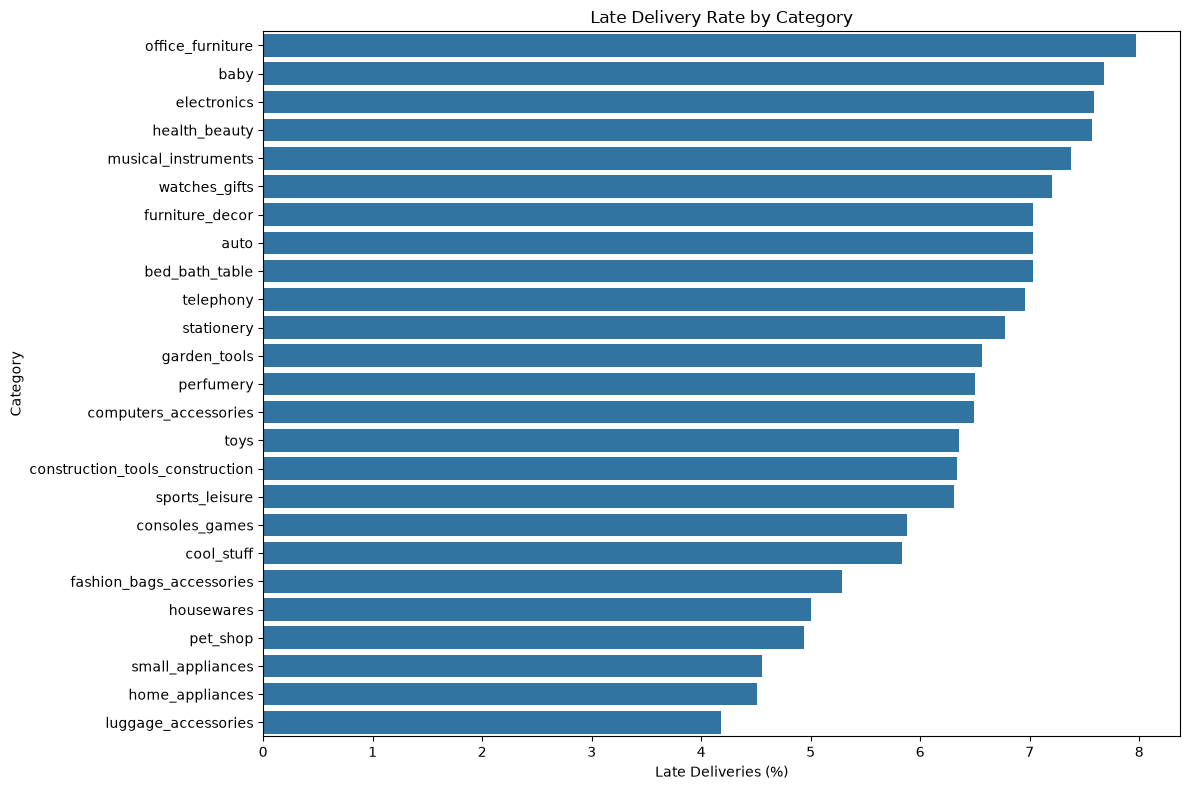

In [56]:
plot_df = (
    category_metrics
    .sort("late_pct", descending=True)
    .to_pandas()
)

plt.figure(figsize=(12, 8))

sns.barplot(
    data=plot_df,
    x="late_pct",
    y="category"
)

plt.title("Late Delivery Rate by Category")
plt.xlabel("Late Deliveries (%)")
plt.ylabel("Category")

plt.tight_layout()

plt.savefig(
    "plots/category_late_delivery_rate.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

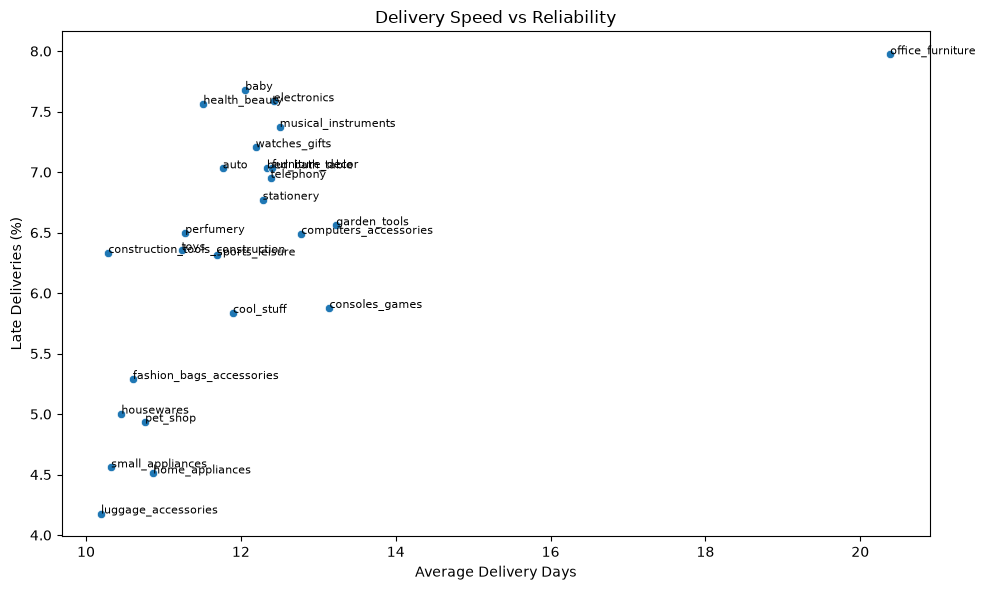

In [57]:
plot_df = category_metrics.to_pandas()

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=plot_df,
    x="avg_delivery_days",
    y="late_pct"
)

for _, row in plot_df.iterrows():
    plt.annotate(
        row["category"],
        (row["avg_delivery_days"], row["late_pct"]),
        fontsize=8
    )

plt.title("Delivery Speed vs Reliability")
plt.xlabel("Average Delivery Days")
plt.ylabel("Late Deliveries (%)")

plt.tight_layout()

plt.savefig(
    "plots/delivery_speed_vs_reliability.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()